In [1]:
pip install numpy pandas scikit-learn matplotlib seaborn xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
data = load_breast_cancer(as_frame=True)
df = data.frame

In [4]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nClass distribution:\n", df['target'].value_counts())
print("\nData types:\n", df.dtypes.unique())

Shape: (569, 31)

Missing values:
 0

Class distribution:
 target
1    357
0    212
Name: count, dtype: int64

Data types:
 [dtype('float64') dtype('int64')]


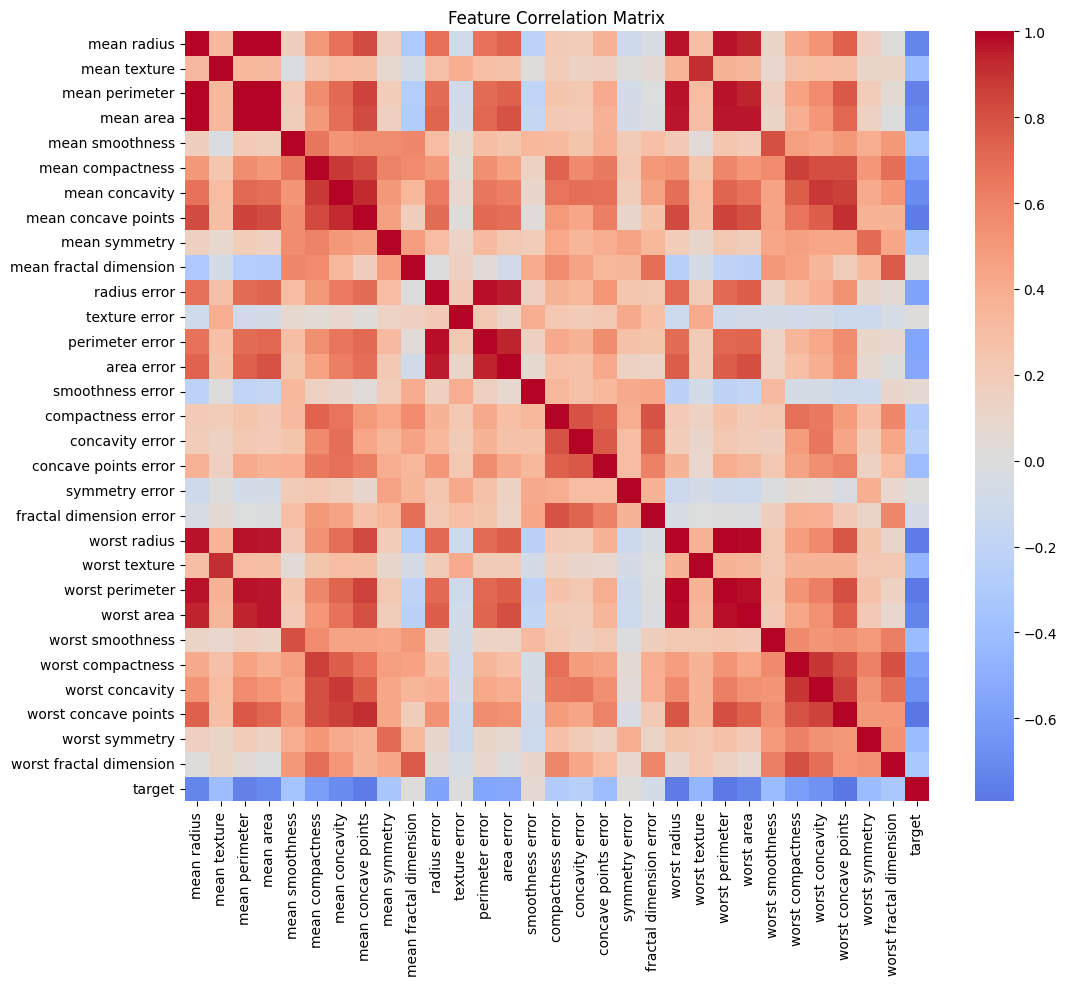

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [6]:
corr_matrix = df.drop("target", axis=1).corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Dropping highly correlated features:", len(to_drop))

X = df.drop(columns=to_drop + ["target"])
y = df["target"]

print("New feature count:", X.shape[1])

Dropping highly correlated features: 10
New feature count: 20


In [7]:
X = df.drop(columns=to_drop + ["target"])
y = df["target"]
print("New feature count:", X.shape[1])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

New feature count: 20


In [8]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

import warnings
warnings.filterwarnings("ignore")

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(n_neighbors=5),
    
    "Naive Bayes": GaussianNB(),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}

In [11]:
results = []

for name, model in models.items():
    
    # Some models need scaled data
    if name in ["Logistic Regression", "KNN", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_proba = y_pred
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_proba = y_pred

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append([
        name,
        accuracy,
        auc,
        precision,
        recall,
        f1,
        mcc
    ])

# Create comparison table
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
])

# Sort by AUC (or Accuracy)
results_df = results_df.sort_values(by="AUC", ascending=False)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
2,KNN,0.964912,0.995040,0.972222,0.972222,0.972222,0.924603
0,Logistic Regression,0.982456,0.994048,0.986111,0.986111,0.986111,0.962302
5,XGBoost,0.956140,0.989418,0.958904,0.972222,0.965517,0.905447
4,Random Forest,0.956140,0.989087,0.946667,0.986111,0.965986,0.905824
3,Naive Bayes,0.885965,0.953373,0.927536,0.888889,0.907801,0.759734
1,Decision Tree,0.912281,0.856647,0.907895,0.958333,0.932432,0.810093


In [12]:
import joblib
import os

os.makedirs("model", exist_ok=True)

# Save scaler
joblib.dump(scaler, "model/scaler.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "model/feature_names.pkl")

# Save trained models
for name, model in models.items():
    file_name = name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model, f"model/{file_name}")

print("All models saved successfully.")

All models saved successfully.


In [13]:
df.sample(50).to_csv("test_data.csv", index=False)